# Customer Churn Prediction for SyriaTel

# 1. BUSINESS UNDERSTANDING
## Business Problem
SyriaTel, a telecommunications company, is experiencing customer churn, which leads to revenue loss. Retaining existing customers is more cost-effective than acquiring new ones.

## Objective
The goal of this project is to build a classification model that predicts whether a customer is likely to churn. This will allow the company to proactively identify at-risk customers and implement retention strategies.

## Stakeholder
The primary stakeholders are SyriaTel’s marketing and customer retention teams, who can use model predictions to target high-risk customers with interventions.

## Success Metric
Recall will be prioritized, as failing to identify customers who churn (false negatives) results in direct revenue loss.

In [1]:
#Importing relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
#Loading dataset
df = pd.read_csv("bigml_59c28831336c6604c800002a.csv")
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


# 2. DATA UNDERSTANDING
This section explores the structure, quality, and basic characteristics of the dataset.

In [3]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (3333, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls     

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [4]:
df.columns

Index(['state', 'account length', 'area code', 'phone number',
       'international plan', 'voice mail plan', 'number vmail messages',
       'total day minutes', 'total day calls', 'total day charge',
       'total eve minutes', 'total eve calls', 'total eve charge',
       'total night minutes', 'total night calls', 'total night charge',
       'total intl minutes', 'total intl calls', 'total intl charge',
       'customer service calls', 'churn'],
      dtype='object')

In [5]:
df['churn'].value_counts()

churn
False    2850
True      483
Name: count, dtype: int64

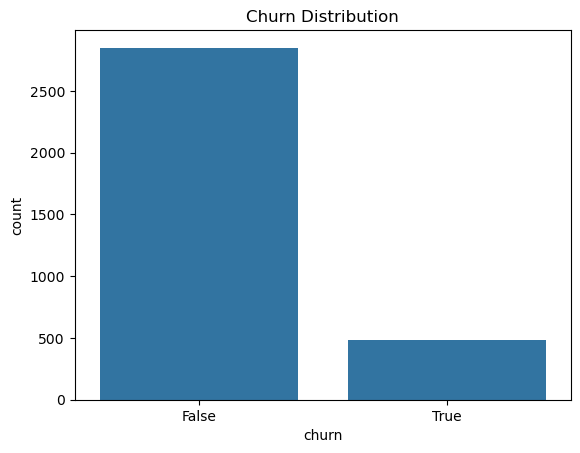

In [6]:
sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.show()

### Target Variable Analysis

The dataset contains 3,333 customers, of which 483 (approximately 14.5%) have churned and 2,850 (85.5%) have not.

This indicates a class imbalance problem, where the majority class (non-churn) significantly outweighs the minority class (churn). This is important because a model that predicts all customers as non-churn would still achieve high accuracy, but would fail to identify customers at risk.

For this reason, accuracy alone is not an appropriate evaluation metric. Instead, recall will be prioritized to ensure that the model correctly identifies as many churned customers as possible.

# 3. DATA PREPARATION

In [7]:
df = df.drop(columns=['phone number', 'state', 'area code'])

### Feature Selection

The following columns were removed:

- Phone number: a unique identifier with no predictive value
- State: high-cardinality categorical variable with limited relevance to churn
- Area code: unlikely to influence customer behavior

Removing these features helps reduce noise and improve model performance.

In [8]:
df.dtypes

account length              int64
international plan         object
voice mail plan            object
number vmail messages       int64
total day minutes         float64
total day calls             int64
total day charge          float64
total eve minutes         float64
total eve calls             int64
total eve charge          float64
total night minutes       float64
total night calls           int64
total night charge        float64
total intl minutes        float64
total intl calls            int64
total intl charge         float64
customer service calls      int64
churn                        bool
dtype: object

In [9]:
df['churn'].unique()

array([False,  True])

In [10]:
df['churn'] = df['churn'].astype(int)

In [11]:
df['churn'].value_counts()

churn
0    2850
1     483
Name: count, dtype: int64

In [12]:
df['international plan'].unique()

array(['no', 'yes'], dtype=object)

In [13]:
df['voice mail plan'].unique()

array(['yes', 'no'], dtype=object)

In [14]:
df['international plan'] = df['international plan'].astype(str).map({'no': 0, 'yes': 1})
df['voice mail plan'] = df['voice mail plan'].astype(str).map({'no': 0, 'yes': 1})

In [15]:
df[['international plan', 'voice mail plan', 'churn']].describe()

,international plan,voice mail plan,churn
count,3333.000000,3333.000000,3333.000000
mean,0.096910,0.276628,0.144914
std,0.295879,0.447398,0.352067
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000


### Encoding Categorical Variables

Categorical variables were converted into numerical format using binary encoding to make them compatible with machine learning algorithms.

- The variables "international plan" and "voice mail plan" were encoded such that "yes" = 1 and "no" = 0.
- The target variable "churn" was encoded as 1 (customer churned) and 0 (customer did not churn).

This transformation is necessary because most machine learning models require numerical input features and cannot directly process categorical data.

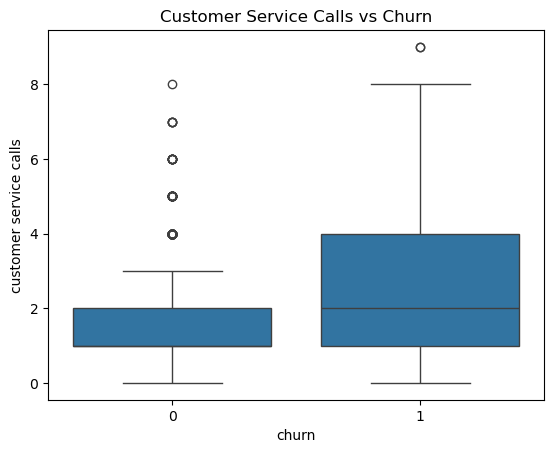

In [16]:
#customer service calls vs churn
sns.boxplot(x='churn', y='customer service calls', data=df)
plt.title("Customer Service Calls vs Churn")
plt.show()

### Customer Service Calls vs Churn

Customers who churn (churn = 1) tend to have a higher number of customer service calls compared to those who do not churn (churn = 0).

The median number of customer service calls is higher for churned customers, and the overall distribution is more spread out, indicating greater variability. Additionally, churned customers exhibit more extreme values (outliers), suggesting that frequent interactions with customer support are strongly associated with churn.

This pattern suggests that unresolved issues, dissatisfaction, or repeated service problems may be key drivers of customer attrition. Therefore, "customer service calls" appears to be a strong predictor of churn and may provide actionable insight for improving customer retention strategies.

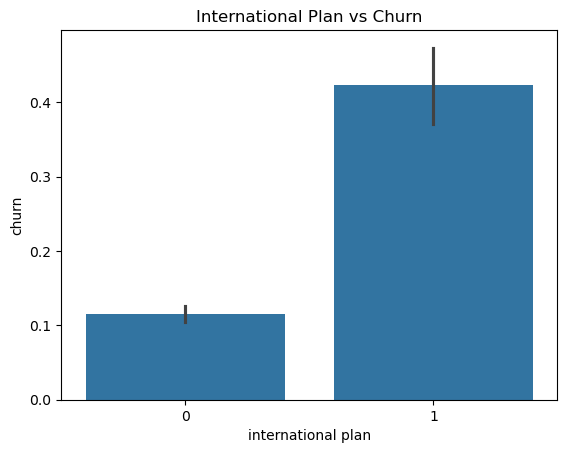

In [17]:
# International Plan vs Churn
sns.barplot(x='international plan', y='churn', data=df)
plt.title("International Plan vs Churn")
plt.show()

### International Plan vs Churn

Customers with an international plan (value = 1) have a significantly higher churn rate compared to customers without an international plan (value = 0).

The churn rate for customers without an international plan is approximately 11%, whereas it increases to over 40% for customers with an international plan. This substantial difference indicates that having an international plan is strongly associated with an increased likelihood of churn.

This suggests that customers using international services may be more sensitive to pricing, service quality, or billing issues. As a result, "international plan" is likely an important predictor for the classification model and may be a key area for targeted retention strategies.

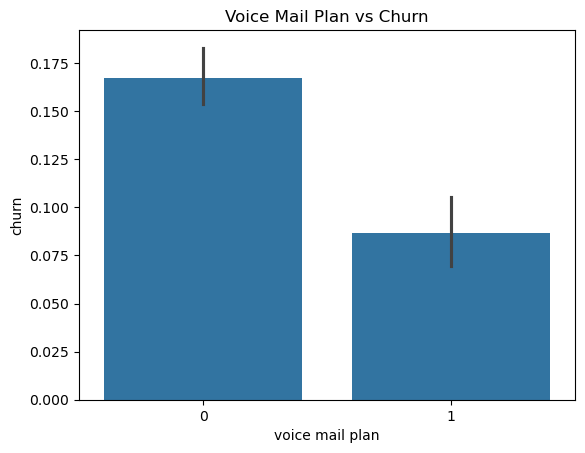

In [18]:
sns.barplot(x='voice mail plan', y='churn', data=df)
plt.title("Voice Mail Plan vs Churn")
plt.show()

### Voice Mail Plan vs Churn

Customers without a voice mail plan (value = 0) have a higher churn rate compared to those with a voice mail plan (value = 1).

The churn rate for customers without a voice mail plan is approximately 16–17%, while it drops to around 8–9% for customers who have a voice mail plan. This suggests that customers who subscribe to additional services, such as voice mail, are less likely to churn.

This may indicate that customers who are more engaged with the company’s services tend to remain loyal. Therefore, the presence of a voice mail plan appears to be associated with reduced churn risk and may serve as a useful predictor in the classification model.

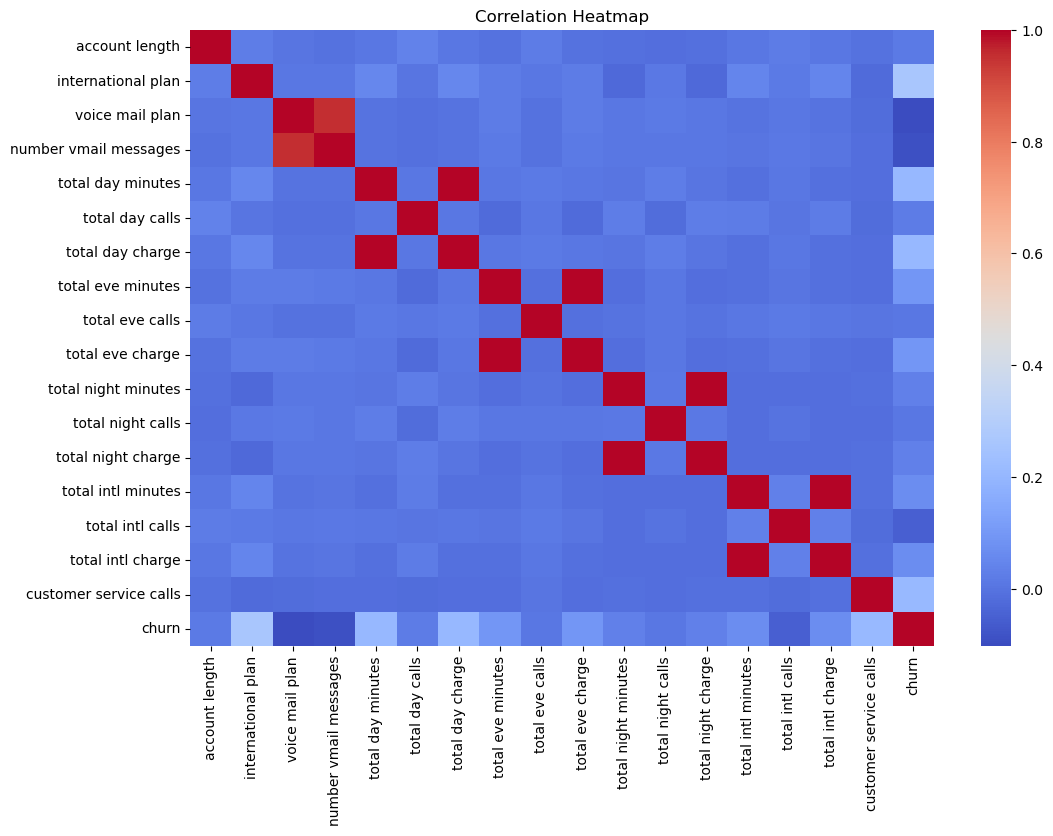

In [19]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Correlation Analysis

The correlation heatmap reveals strong relationships between several pairs of features, particularly between usage metrics and their corresponding charges.

For example:
- "total day minutes" and "total day charge" are highly correlated
- "total eve minutes" and "total eve charge" are highly correlated
- "total night minutes" and "total night charge" are highly correlated
- "total intl minutes" and "total intl charge" are highly correlated

These strong correlations indicate redundancy, as charges are directly derived from usage minutes. Including both variables in the model may introduce multicollinearity without adding new information.

Additionally, "voice mail plan" and "number vmail messages" show a strong relationship, which is expected since voicemail usage depends on having a voicemail plan.

In relation to the target variable (churn), no single feature shows an extremely strong linear correlation. However, features such as "customer service calls" and "international plan" exhibit relatively stronger relationships with churn compared to other variables, supporting earlier findings from exploratory analysis.

Based on this analysis, it may be beneficial to remove redundant features (such as charge variables) to simplify the model without significantly reducing predictive power.

In [20]:
df = df.drop(columns=[
    'total day charge',
    'total eve charge',
    'total night charge',
    'total intl charge'
])

### Feature Reduction

Highly correlated charge variables were removed because they are directly derived from usage minutes and do not provide additional information. Removing these redundant features helps reduce multicollinearity and simplifies the model without sacrificing predictive performance.

# 4. MODELING

In [21]:
X = df.drop(columns='churn')
y = df['churn']

In [22]:
#splitting the data into training and testing set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Feature Scaling
Feature scaling was applied using StandardScaler to standardize the feature values. The scaler was fit on the training data and then applied to both the training and test sets.
This approach prevented data leakage and ensured that the model generalizes well to unseen data.

### Model 1: Logistic Regression

In [24]:
#fitting the base model
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [25]:
#making prediction
y_pred = log_reg.predict(X_test_scaled)

In [26]:
#evakuating the base model
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[549  21]
 [ 73  24]]
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       570
           1       0.53      0.25      0.34        97

    accuracy                           0.86       667
   macro avg       0.71      0.61      0.63       667
weighted avg       0.83      0.86      0.84       667



### Logistic Regression Model Evaluation

The logistic regression model achieved an overall accuracy of 86%. However, accuracy is not an appropriate metric for this problem due to class imbalance.

For the churn class (1), the model achieved:
- Precision: 0.53
- Recall: 0.25
- F1-score: 0.34

While the model performs well in identifying non-churn customers (recall = 0.96), it performs poorly in identifying churners, correctly identifying only 25% of them. The confusion matrix shows that 73 churners were incorrectly classified as non-churn.

This is a significant limitation because failing to identify customers who are likely to churn directly impacts business outcomes. Since recall is critical in this context, the model is not performing adequately.

This baseline model highlights the need for a more advanced approach that can better capture patterns associated with churn and improve recall performance.

### Improving the Logistic Regression Model using class weighting

In [27]:
log_reg_balanced = LogisticRegression(
    random_state=42,
    class_weight='balanced'
)

log_reg_balanced.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [28]:
y_pred_bal = log_reg_balanced.predict(X_test_scaled)

In [29]:
print(confusion_matrix(y_test, y_pred_bal))
print(classification_report(y_test, y_pred_bal))

[[435 135]
 [ 25  72]]
              precision    recall  f1-score   support

           0       0.95      0.76      0.84       570
           1       0.35      0.74      0.47        97

    accuracy                           0.76       667
   macro avg       0.65      0.75      0.66       667
weighted avg       0.86      0.76      0.79       667



### Improved Logistic Regression Model Evaluation

To address class imbalance, logistic regression was re-trained using class_weight='balanced'. This significantly improved the model’s ability to identify churners.

The recall for the churn class increased from 0.25 to 0.74, meaning the model now correctly identifies approximately 74% of customers who churn. The number of missed churners decreased from 73 to 25, representing a substantial improvement.

However, this improvement comes with a trade-off. Precision for the churn class decreased to 0.35, indicating that a larger proportion of predicted churners are false positives. Additionally, overall accuracy dropped from 0.86 to 0.76.

Despite these trade-offs, the improved recall is more valuable in this context, as failing to identify churners results in lost revenue. Therefore, this adjusted logistic regression model is better aligned with the business objective.

### Model 2: Decision Tree

In [30]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

[[540  30]
 [ 34  63]]
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       570
           1       0.68      0.65      0.66        97

    accuracy                           0.90       667
   macro avg       0.81      0.80      0.80       667
weighted avg       0.90      0.90      0.90       667



### Decision Tree Model Evaluation (Baseline)

The Decision Tree model achieved strong overall performance, with an accuracy of 90%.

For the churn class (1), the model achieved:
- Precision: 0.68
- Recall: 0.65
- F1-score: 0.66

Compared to logistic regression, the Decision Tree provides a better balance between precision and recall. While the balanced logistic regression model achieved higher recall (0.74), it did so at the cost of much lower precision (0.35). In contrast, the Decision Tree maintains both relatively high recall and significantly improved precision.

The confusion matrix shows that the model correctly identified 63 churners while missing 34, which is a substantial improvement over the baseline logistic regression model.

These results suggest that the Decision Tree is better suited for capturing the underlying patterns in the data, likely due to its ability to model non-linear relationships and feature interactions.

### Tuning the Decision Tree Model

In [31]:
dt_tuned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_tuned.fit(X_train, y_train)

y_pred_dt_tuned = dt_tuned.predict(X_test)

print(confusion_matrix(y_test, y_pred_dt_tuned))
print(classification_report(y_test, y_pred_dt_tuned))

[[550  20]
 [ 34  63]]
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       570
           1       0.76      0.65      0.70        97

    accuracy                           0.92       667
   macro avg       0.85      0.81      0.83       667
weighted avg       0.92      0.92      0.92       667



### Decision Tree Model Evaluation (Tuned)

The tuned Decision Tree model achieved strong overall performance, with an accuracy of 92%.

For the churn class (1), the model achieved:
- Precision: 0.76
- Recall: 0.65
- F1-score: 0.70

Compared to the baseline Decision Tree, tuning improved precision from 0.68 to 0.76 while maintaining the same recall (0.65). This indicates that the model produces fewer false positives while still identifying a similar number of churners.

The confusion matrix shows that the model correctly identified 63 churners and reduced false positive predictions from 30 to 20. This improvement suggests that the tuned model generalizes better and is less prone to overfitting.

Overall, the tuned Decision Tree provides a strong balance between precision and recall, making it a reliable model for identifying customers at risk of churn.

### Model comparison and Selection

### Final Model Selection

Four models were evaluated: baseline logistic regression, class-balanced logistic regression, baseline Decision Tree and a tuned Decision Tree.

The baseline logistic regression model performed poorly in identifying churners, with a recall of only 0.25. The balanced logistic regression improved recall to 0.74 but produced a large number of false positives, resulting in low precision (0.35).

The tuned Decision Tree model achieved a more balanced performance, with a recall of 0.65 and a precision of 0.76, while also achieving the highest overall accuracy (0.92). This indicates that the model is able to identify a substantial portion of churners while minimizing false alarms.

Based on this comparison, the tuned Decision Tree model was selected as the final model because it provides the best trade-off between identifying churners and maintaining prediction reliability.

# 6. DEPLOYMENT

### Business Recommendations

Based on the model results and exploratory analysis, several key factors contribute to customer churn:

- Customers with frequent customer service calls are more likely to churn, suggesting dissatisfaction or unresolved issues
- Customers with international plans exhibit significantly higher churn rates
- Customers with voice mail plans are less likely to churn, indicating that engagement with additional services may improve retention

To reduce churn, SyriaTel should:

- Improve customer service quality and reduce the need for repeated support interactions
- Investigate pricing and service quality for international plan customers
- Encourage adoption of additional services such as voice mail to increase customer engagement

The model can be used to proactively identify high-risk customers and target them with retention strategies such as promotions, service improvements, or personalized support.